# Sokoban A* Heuristic Optimization — Visualization

Slide-ready charts for the LLM-driven heuristic optimization pipeline.  
Loads results from `optimization_results.json` produced by `heuristic_optimizer.py`.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Style settings (tweak these for your slides) ─────────────────
FONT_SIZE    = 13
TITLE_SIZE   = 16
FIG_W, FIG_H = 14, 5        # default figure width / height
BAR_WIDTH    = 0.22          # width of each bar in grouped charts
DPI          = 150           # export resolution
SAVE_FIGS    = False         # set True to auto-save PNGs

COLORS = {
    'naive_manhattan': '#d29922',
    'greedy_matching': '#bc8cff',
    'enhanced':        '#58a6ff',
    'llm_best':        '#3fb950',
    'accepted':        '#3fb950',
    'rejected':        '#f85149',
    'baseline':        '#58a6ff',
}

plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.titlesize': TITLE_SIZE,
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'savefig.dpi': DPI,
    'savefig.bbox': 'tight',
})

def save(fig, name):
    if SAVE_FIGS:
        fig.savefig(f'figures/{name}.png')
        print(f'Saved figures/{name}.png')

In [2]:
# ── Load data ─────────────────────────────────────────────────────
with open('optimization_results.json') as f:
    data = json.load(f)

levels     = data['levels']
baselines  = data['baselines']
iterations = data['iterations']
best_info  = data['best']

# Convenience: per-level node arrays for each baseline
naive_nodes    = [r['nodes'] for r in baselines['naive_manhattan']['results']]
greedy_nodes   = [r['nodes'] for r in baselines['greedy_matching']['results']]
enhanced_nodes = [r['nodes'] for r in baselines['enhanced']['results']]

# Best LLM iteration
best_iter = [it for it in iterations if it['accepted']][-1]
llm_nodes = [r['nodes'] for r in best_iter['results']]

print(f'Levels: {len(levels)}')
print(f'Iterations: {len(iterations)} ({sum(1 for it in iterations if it["accepted"])} accepted)')
print(f'Naive total:    {sum(naive_nodes):>8,}')
print(f'Greedy total:   {sum(greedy_nodes):>8,}')
print(f'Enhanced total: {sum(enhanced_nodes):>8,}')
print(f'LLM Best total: {sum(llm_nodes):>8,}')

Levels: 30
Iterations: 6 (3 accepted)
Naive total:      34,830
Greedy total:     32,582
Enhanced total:   33,257
LLM Best total:    9,573


## 1. Optimization Timeline

Total nodes explored per iteration — accepted vs rejected.

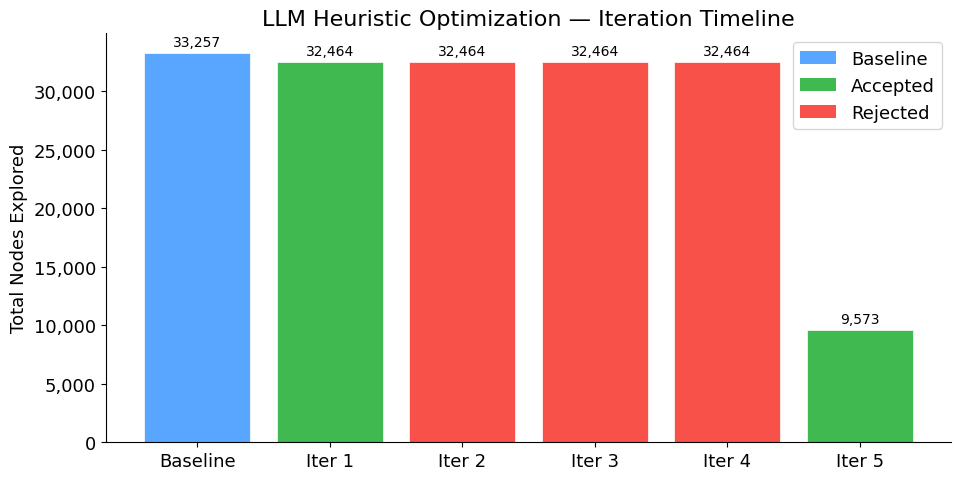

In [3]:
fig, ax = plt.subplots(figsize=(FIG_W * 0.7, FIG_H))

iter_labels = []
iter_nodes  = []
iter_colors = []

for it in iterations:
    label = 'Baseline' if it['iteration'] == 0 else f"Iter {it['iteration']}"
    iter_labels.append(label)
    total = sum(r['nodes'] for r in it['results'])
    iter_nodes.append(total)
    if it['iteration'] == 0:
        iter_colors.append(COLORS['baseline'])
    elif it['accepted']:
        iter_colors.append(COLORS['accepted'])
    else:
        iter_colors.append(COLORS['rejected'])

bars = ax.bar(iter_labels, iter_nodes, color=iter_colors, edgecolor='white', linewidth=0.5)

# Value labels on top
for bar, val in zip(bars, iter_nodes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(iter_nodes)*0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Total Nodes Explored')
ax.set_title('LLM Heuristic Optimization — Iteration Timeline')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor=COLORS['baseline'], label='Baseline'),
    Patch(facecolor=COLORS['accepted'], label='Accepted'),
    Patch(facecolor=COLORS['rejected'], label='Rejected'),
]
ax.legend(handles=legend_elems, loc='upper right')

plt.tight_layout()
save(fig, 'timeline')
plt.show()

## 2. Per-Level Node Comparison (Grouped Bar)

Compare all heuristics side by side for each level.

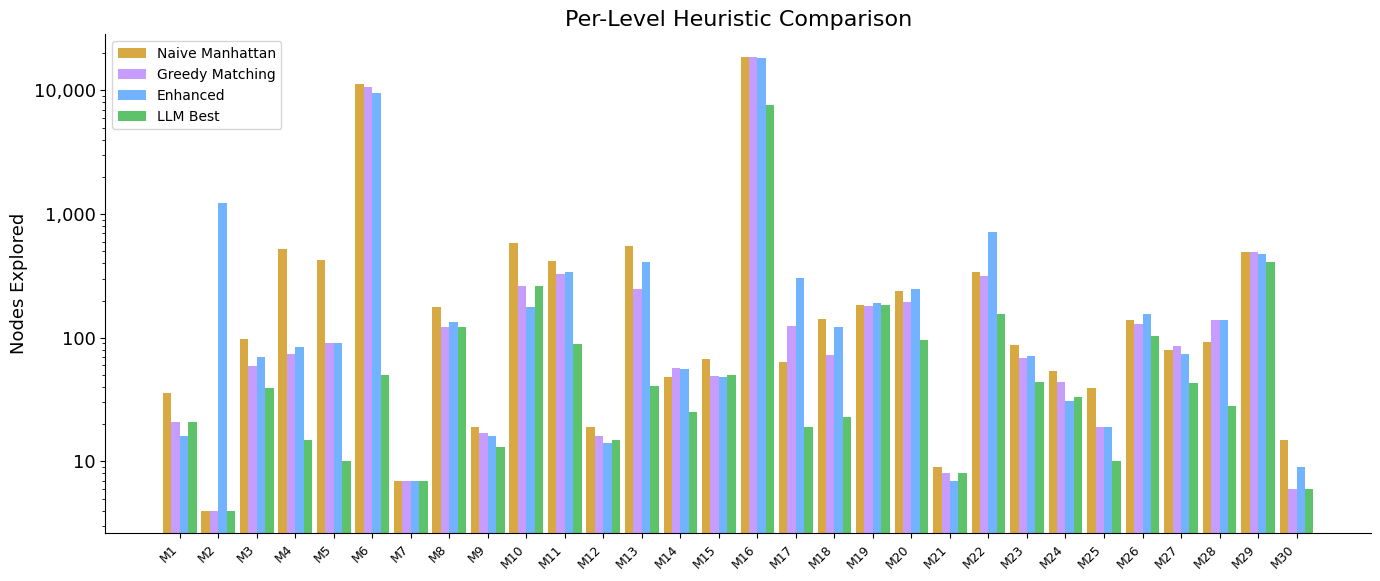

In [4]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 1))

x = np.arange(len(levels))
w = BAR_WIDTH

ax.bar(x - 1.5*w, naive_nodes,    w, label='Naive Manhattan', color=COLORS['naive_manhattan'], alpha=0.85)
ax.bar(x - 0.5*w, greedy_nodes,   w, label='Greedy Matching', color=COLORS['greedy_matching'], alpha=0.85)
ax.bar(x + 0.5*w, enhanced_nodes, w, label='Enhanced',        color=COLORS['enhanced'],        alpha=0.85)
ax.bar(x + 1.5*w, llm_nodes,      w, label='LLM Best',        color=COLORS['llm_best'],        alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([l.replace('Microban ', 'M') for l in levels],
                    rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Nodes Explored')
ax.set_title('Per-Level Heuristic Comparison')
ax.set_yscale('log')
ax.legend(loc='upper left', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
save(fig, 'per_level_comparison')
plt.show()

## 3. Improvement Heatmap

Shows percentage improvement of LLM Best vs Enhanced baseline per level.

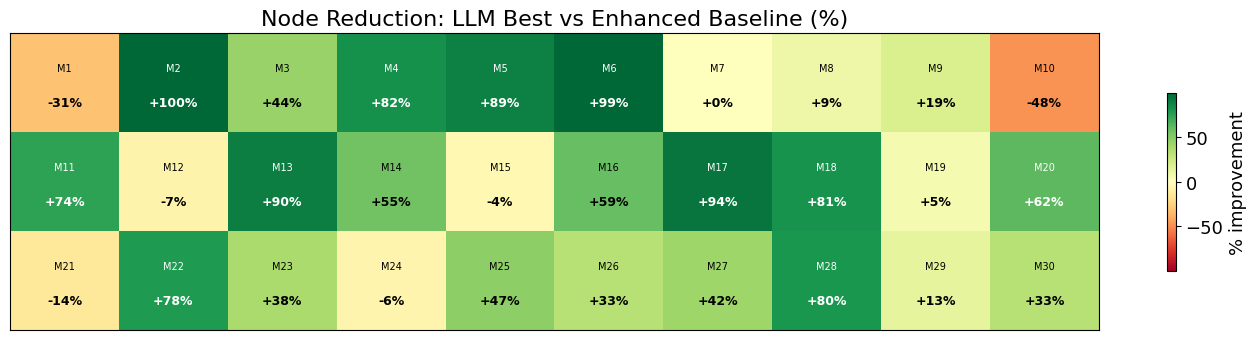

In [5]:
improvements = []
for e, l in zip(enhanced_nodes, llm_nodes):
    imp = (e - l) / e * 100 if e > 0 else 0
    improvements.append(imp)

# Reshape for heatmap (single row or multi-row)
n = len(levels)
cols = min(n, 10)
rows = (n + cols - 1) // cols
padded = improvements + [0] * (rows * cols - n)
heat = np.array(padded).reshape(rows, cols)
labels_grid = levels + [''] * (rows * cols - n)
labels_2d = np.array(labels_grid).reshape(rows, cols)

fig, ax = plt.subplots(figsize=(FIG_W, max(2, rows * 1.2)))

cmap = plt.cm.RdYlGn  # red=worse, green=better
vmax = max(abs(min(improvements)), abs(max(improvements)), 1)
im = ax.imshow(heat, cmap=cmap, aspect='auto', vmin=-vmax, vmax=vmax)

# Annotations
for i in range(rows):
    for j in range(cols):
        idx = i * cols + j
        if idx >= n:
            continue
        val = improvements[idx]
        short = levels[idx].replace('Microban ', 'M')
        color = 'white' if abs(val) > vmax * 0.6 else 'black'
        ax.text(j, i - 0.15, short, ha='center', va='center', fontsize=7, color=color)
        ax.text(j, i + 0.2, f'{val:+.0f}%', ha='center', va='center',
                fontsize=9, fontweight='bold', color=color)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Node Reduction: LLM Best vs Enhanced Baseline (%)')
plt.colorbar(im, ax=ax, label='% improvement', shrink=0.6)

plt.tight_layout()
save(fig, 'improvement_heatmap')
plt.show()

## 4. Summary Table

Total nodes for each heuristic with improvement percentages.

In [6]:
import pandas as pd

rows_data = []
for i, name in enumerate(levels):
    e = enhanced_nodes[i]
    l = llm_nodes[i]
    imp = (e - l) / e * 100 if e > 0 else 0
    rows_data.append({
        'Level': name,
        'Naive Manhattan': naive_nodes[i],
        'Greedy Matching': greedy_nodes[i],
        'Enhanced': e,
        'LLM Best': l,
        'Improvement (%)': round(imp, 1),
    })

df = pd.DataFrame(rows_data)

# Add totals row
totals = {
    'Level': 'TOTAL',
    'Naive Manhattan': sum(naive_nodes),
    'Greedy Matching': sum(greedy_nodes),
    'Enhanced': sum(enhanced_nodes),
    'LLM Best': sum(llm_nodes),
    'Improvement (%)': round((sum(enhanced_nodes) - sum(llm_nodes)) / sum(enhanced_nodes) * 100, 1),
}
df = pd.concat([df, pd.DataFrame([totals])], ignore_index=True)

# Style: highlight improvement column
def color_improvement(val):
    if isinstance(val, (int, float)):
        if val > 0:
            return 'color: green; font-weight: bold'
        elif val < 0:
            return 'color: red; font-weight: bold'
    return ''

styled = df.style.map(color_improvement, subset=['Improvement (%)'])
styled = styled.format({
    'Naive Manhattan': '{:,}',
    'Greedy Matching': '{:,}',
    'Enhanced': '{:,}',
    'LLM Best': '{:,}',
    'Improvement (%)': '{:+.1f}%',
})
styled

,Level,Naive Manhattan,Greedy Matching,Enhanced,LLM Best,Improvement (%)
0,Microban 1,36,21,16,21,-31.2%
1,Microban 2,4,4,"1,223",4,+99.7%
2,Microban 3,98,59,70,39,+44.3%
3,Microban 4,518,74,84,15,+82.1%
4,Microban 5,422,91,91,10,+89.0%
5,Microban 6,"11,257","10,686","9,561",50,+99.5%
6,Microban 7,7,7,7,7,+0.0%
7,Microban 8,177,122,134,122,+9.0%
8,Microban 9,19,17,16,13,+18.8%
9,Microban 10,586,263,178,263,-47.8%


## 5. Radar Chart — Heuristic Profile

Normalized performance across a subset of representative levels.

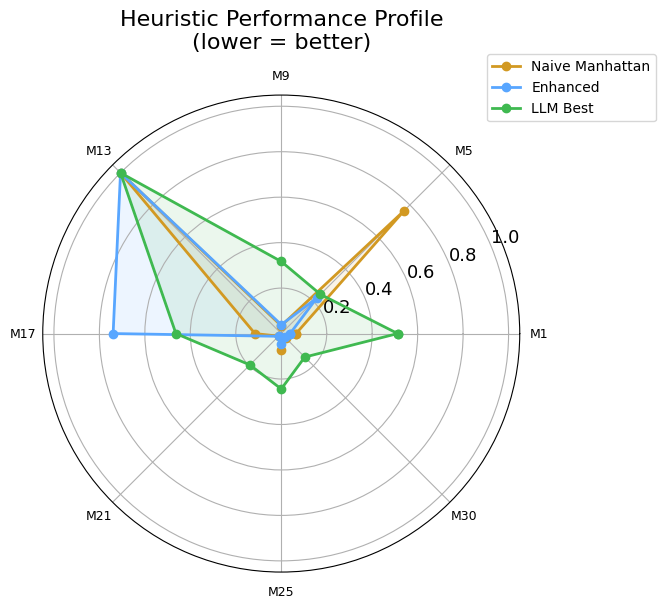

In [7]:
# Pick representative levels (spread across difficulty)
n_levels = len(levels)
indices = np.linspace(0, n_levels - 1, min(8, n_levels), dtype=int)
radar_levels = [levels[i] for i in indices]

# Normalize each level's nodes to [0, 1] where 1 = worst (most nodes)
def normalize(nodes_list, indices):
    vals = [nodes_list[i] for i in indices]
    mx = max(vals) if max(vals) > 0 else 1
    return [v / mx for v in vals]

naive_norm    = normalize(naive_nodes, indices)
enhanced_norm = normalize(enhanced_nodes, indices)
llm_norm      = normalize(llm_nodes, indices)

angles = np.linspace(0, 2 * np.pi, len(radar_levels), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for data_norm, label, color in [
    (naive_norm,    'Naive Manhattan', COLORS['naive_manhattan']),
    (enhanced_norm, 'Enhanced',        COLORS['enhanced']),
    (llm_norm,      'LLM Best',        COLORS['llm_best']),
]:
    vals = data_norm + data_norm[:1]
    ax.plot(angles, vals, 'o-', label=label, color=color, linewidth=2)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([l.replace('Microban ', 'M') for l in radar_levels], fontsize=9)
ax.set_title('Heuristic Performance Profile\n(lower = better)', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
save(fig, 'radar_profile')
plt.show()

## 6. Cumulative Nodes Across Levels

Shows how total node count accumulates as levels get harder.

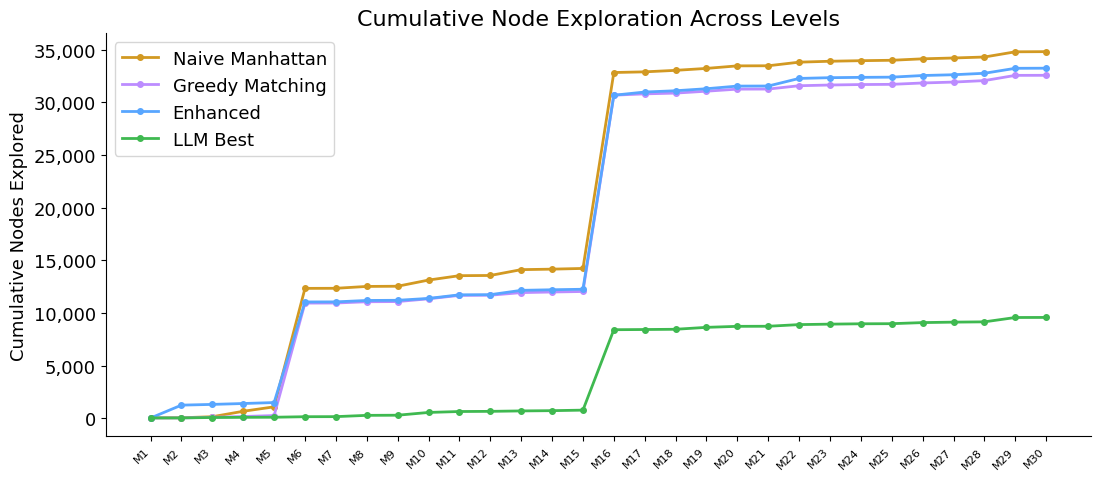

In [8]:
fig, ax = plt.subplots(figsize=(FIG_W * 0.8, FIG_H))

for nodes_list, label, color in [
    (naive_nodes,    'Naive Manhattan', COLORS['naive_manhattan']),
    (greedy_nodes,   'Greedy Matching', COLORS['greedy_matching']),
    (enhanced_nodes, 'Enhanced',        COLORS['enhanced']),
    (llm_nodes,      'LLM Best',        COLORS['llm_best']),
]:
    cumulative = np.cumsum(nodes_list)
    ax.plot(range(len(levels)), cumulative, '-o', label=label, color=color,
            linewidth=2, markersize=4)

ax.set_xticks(range(len(levels)))
ax.set_xticklabels([l.replace('Microban ', 'M') for l in levels],
                    rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Cumulative Nodes Explored')
ax.set_title('Cumulative Node Exploration Across Levels')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
save(fig, 'cumulative_nodes')
plt.show()

## 7. LLM Iteration Improvement Waterfall

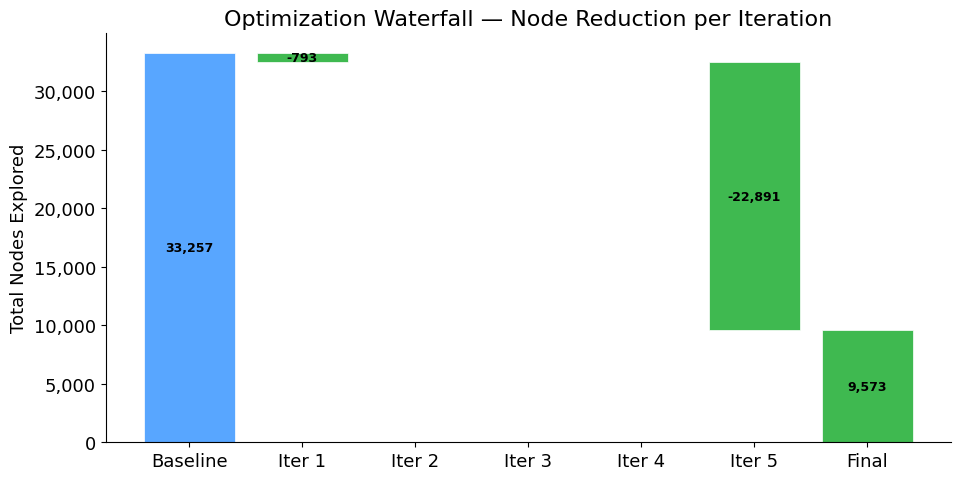

In [9]:
fig, ax = plt.subplots(figsize=(FIG_W * 0.7, FIG_H))

prev_nodes = sum(r['nodes'] for r in iterations[0]['results'])
labels_wf = ['Baseline']
deltas    = [prev_nodes]
colors_wf = [COLORS['baseline']]
bottoms   = [0]

running = prev_nodes
for it in iterations[1:]:
    cur_nodes = sum(r['nodes'] for r in it['results'])
    delta = cur_nodes - prev_nodes if it['accepted'] else 0
    labels_wf.append(f"Iter {it['iteration']}")
    if it['accepted']:
        deltas.append(delta)
        colors_wf.append(COLORS['accepted'] if delta < 0 else COLORS['rejected'])
        bottoms.append(running + delta if delta < 0 else running)
        running += delta
        prev_nodes = cur_nodes
    else:
        deltas.append(0)
        colors_wf.append('#555')
        bottoms.append(running)

# Final bar
labels_wf.append('Final')
deltas.append(running)
colors_wf.append(COLORS['llm_best'])
bottoms.append(0)

ax.bar(labels_wf, [abs(d) for d in deltas], bottom=bottoms,
       color=colors_wf, edgecolor='white', linewidth=0.5)

for i, (lbl, d) in enumerate(zip(labels_wf, deltas)):
    if d != 0:
        y = bottoms[i] + abs(d) / 2
        txt = f'{d:+,}' if i > 0 and i < len(labels_wf)-1 else f'{d:,}'
        ax.text(i, y, txt, ha='center', va='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Total Nodes Explored')
ax.set_title('Optimization Waterfall — Node Reduction per Iteration')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
save(fig, 'waterfall')
plt.show()

## 8. Best LLM Heuristic Source Code

In [10]:
from IPython.display import display, Markdown

source = best_info.get('source', 'N/A')
display(Markdown(f'```python\n{source}\n```'))

```python
def heuristic(board: Board, boxes: tuple[Pos, ...]) -> int:
    """
    Admissible push‑distance heuristic.
    1. Pre‑compute, once per board, the minimum number of pushes required
       to move a box from any free cell to each goal, ignoring other boxes.
    2. Build a cost matrix box‑×‑goal with those distances (INF if unreachable).
    3. Solve the assignment problem exactly with a DP over subsets
       (optimal for ≤ 12 boxes, which covers all Microban levels).
    4. If any box cannot reach any goal (dead‑locked), return a large value.
    """
    from collections import deque

    INF = 10 ** 6  # large enough to dominate any realistic solution cost

    # ---------- 1. static push‑distance maps (cached on board) ----------
    if not hasattr(board, "_push_dist_maps"):
        # distance maps: one dict per goal → {Pos: push_distance}
        push_maps = []
        walls = board.walls
        w, h = board.width, board.height
        for g in board.goals:
            dist = {g: 0}
            q = deque([g])
            while q:
                cur = q.popleft()
                dcur = dist[cur]
                for dx, dy in ((0, -1), (1, 0), (0, 1), (-1, 0)):
                    # reverse a push: box would have come from (cur - dir)
                    prev = Pos(cur.x - dx, cur.y - dy)
                    player_needed = Pos(prev.x - dx, prev.y - dy)
                    if (prev in walls) or (player_needed in walls):
                        continue
                    if prev not in dist:
                        dist[prev] = dcur + 1
                        q.append(prev)
            push_maps.append(dist)
        board._push_dist_maps = push_maps  # cache
    else:
        push_maps = board._push_dist_maps

    # ---------- 2. build cost matrix ----------
    n_boxes = len(boxes)
    n_goals = len(board.goals)
    cost = [[INF] * n_goals for _ in range(n_boxes)]

    for bi, bpos in enumerate(boxes):
        reachable = False
        for gi, gmap in enumerate(push_maps):
            d = gmap.get(bpos)
            if d is not None:
                reachable = True
                cost[bi][gi] = d
        if not reachable:
            # box can never reach any goal → dead‑lock
            return INF

    # ---------- 3. exact minimum‑cost assignment (DP over subsets) ----------
    # dp[mask] = minimal cost after assigning first k boxes to the goals set in mask
    full_mask = (1 << n_goals) - 1
    dp = [INF] * (1 << n_goals)
    dp[0] = 0

    for i in range(n_boxes):
        new_dp = [INF] * (1 << n_goals)
        for mask in range(1 << n_goals):
            cur_cost = dp[mask]
            if cur_cost == INF:
                continue
            # try to assign box i to any unused goal j
            free = (~mask) & full_mask
            while free:
                j = (free & -free).bit_length() - 1
                nmask = mask | (1 << j)
                nd = cur_cost + cost[i][j]
                if nd < new_dp[nmask]:
                    new_dp[nmask] = nd
                free &= free - 1
        dp = new_dp

    best = dp[full_mask]
    return best if best < INF else INF
```

---

### Export Settings

Set `SAVE_FIGS = True` in the first cell and re-run all to save PNGs to `figures/`.

To customize colors, sizes, or chart types, edit the `COLORS`, `FIG_W/FIG_H`, and `FONT_SIZE` variables at the top.